# Round 001 — ตระกูล A: สัญญาณเดี่ยว

**ทำอะไร:** ทดสอบสัญญาณพื้นฐาน 15 ตัว (+ ตัวกรอง 3 แบบ) ทีละตัวภายใต้เกณฑ์ `PREREG_AUTORUN.md`

**อุปมา:** เหมือนคัดนักวิ่งทีละคนว่ามีใครวิ่งชนะ 'ค่าเฉลี่ยของทั้งสนาม' (EW) และ 'นักวิ่งตัวเต็ง' (SPY) ขาดลอยไหม และต้องชนะซ้ำได้หลายสนาม ไม่ใช่ชนะเพราะลมส่งวันเดียว

**อ่านผลอย่างไร:** แถบสีเขียวในกราฟ = ผ่าน S1; ผู้เข้ารอบต้องผ่าน S1+S2+S3(DSR ≥ 0.95)+S6 — สเปกเต็มใน `rounds/round_001/HYPOTHESIS.md`

In [1]:
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
from IPython.display import Image, Markdown, display
from lib import report
report.banner()
r = pd.read_csv("../rounds/round_001/results.csv")
cols = ["trial_id","dec_sharpe","dec_sharpe_ew","dec_sharpe_spy","dec_cagr","dec_cagr_ew","dec_maxdd","dec_maxdd_ew",
        "S1_10","S1_25","S2_share","DSR","S6_avg_n","S6_min_n","info_sharpe","info_sharpe_ew"]
pd.set_option("display.width", 250)
display(r[cols].round(3))
print("ผู้เข้ารอบ (S1+S2+S3+S6):", list(r[r.S1.astype(str).str.lower().eq("true") & r.S2.astype(str).str.lower().eq("true") & r.S3.astype(str).str.lower().eq("true") & r.S6.astype(str).str.lower().eq("true")].trial_id))


> ⚠️ **คำเตือน survivorship bias (แสดงในทุก notebook)**
> รายชื่อสมาชิกมาจาก fja05680/sp500 (point-in-time) แต่ **ราคามาจาก yfinance ซึ่งเก็บเฉพาะหุ้นที่ยังซื้อขายอยู่**
> หุ้นที่ถูกซื้อกิจการ/ล้มละลาย/เปลี่ยนชื่อจำนวนหนึ่งจึงไม่มีราคา และหลุดออกจาก backtest
> ผลตอบแทนที่คำนวณได้จึงมีแนวโน้ม **สูงกว่าความจริง** (หุ้นที่ "ตาย" ไปมักเป็นหุ้นที่ผลตอบแทนแย่)
> สัดส่วนที่ขาดหายวัดไว้ใน `v0_data_audit.ipynb`

> ⚠️ **ข้อจำกัดของ held-out**: held-out = rebalance มิ.ย. 2023, 2024, 2025 (3 รอบเต็ม) + มิ.ย. 2026 ที่ถือได้แค่ ~3 เดือน
> (รอบ 2026 เป็นข้อมูลประกอบ ไม่นับตัดสิน) — มีแค่ 2–3 รอบ rebalance ที่ใช้ตัดสิน ผลช่วงนี้จึงมีความไม่แน่นอนสูงมาก
> ใช้เป็นการตรวจทิศทางเท่านั้น ไม่ใช่หลักฐานทางสถิติ


,trial_id,dec_sharpe,dec_sharpe_ew,dec_sharpe_spy,dec_cagr,dec_cagr_ew,dec_maxdd,dec_maxdd_ew,S1_10,S1_25,S2_share,DSR,S6_avg_n,S6_min_n,info_sharpe,info_sharpe_ew
0,r001_Q_GPA_overall,0.775,0.64,0.681,0.161,0.125,-0.351,-0.376,False,False,1.000,0.399,51.417,50,1.006,1.137
1,r001_Q_GPA_sector,0.769,0.64,0.681,0.157,0.125,-0.352,-0.376,False,False,1.000,0.335,51.417,50,1.014,1.137
2,r001_Q_ROIC_overall,0.817,0.64,0.681,0.165,0.125,-0.332,-0.376,False,False,0.973,0.421,54.333,50,0.942,1.137
3,r001_Q_ROIC_sector,0.762,0.64,0.681,0.147,0.125,-0.351,-0.376,False,False,0.892,0.241,54.333,50,1.244,1.137
4,r001_Q_LOWACC_overall,0.863,0.64,0.681,0.186,0.125,-0.362,-0.376,True,True,1.000,0.860,63.250,51,0.787,1.137
5,r001_Q_LOWACC_sector,0.812,0.64,0.681,0.169,0.125,-0.367,-0.376,False,False,1.000,0.700,63.250,51,0.921,1.137
6,r001_V_BM_overall,0.484,0.64,0.681,0.109,0.125,-0.494,-0.376,False,False,0.405,0.040,63.667,51,1.116,1.137
7,r001_V_BM_sector,0.514,0.64,0.681,0.113,0.125,-0.446,-0.376,False,False,0.216,0.041,63.667,51,1.036,1.137
8,r001_V_EP_overall,0.475,0.64,0.681,0.103,0.125,-0.470,-0.376,False,False,0.351,0.020,63.417,51,0.991,1.137
9,r001_V_EP_sector,0.535,0.64,0.681,0.113,0.125,-0.428,-0.376,False,False,0.405,0.024,63.417,51,0.990,1.137


ผู้เข้ารอบ (S1+S2+S3+S6): []


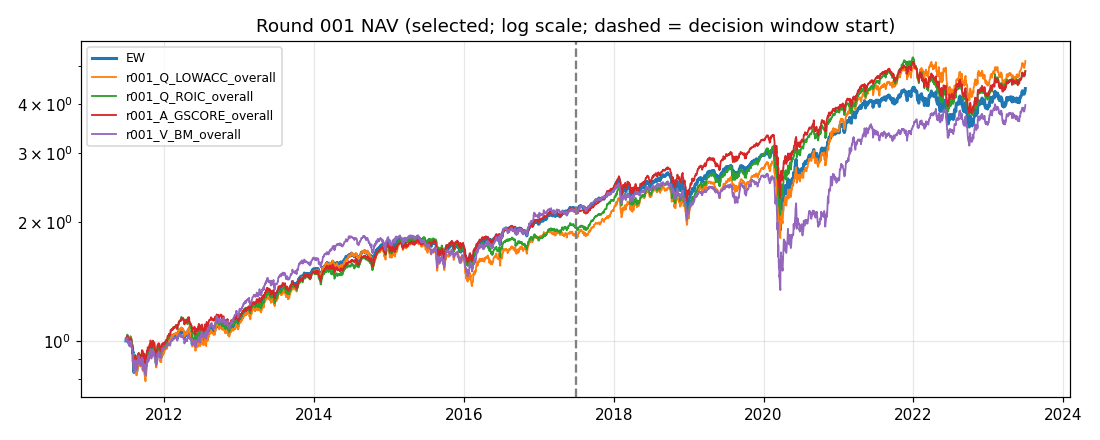

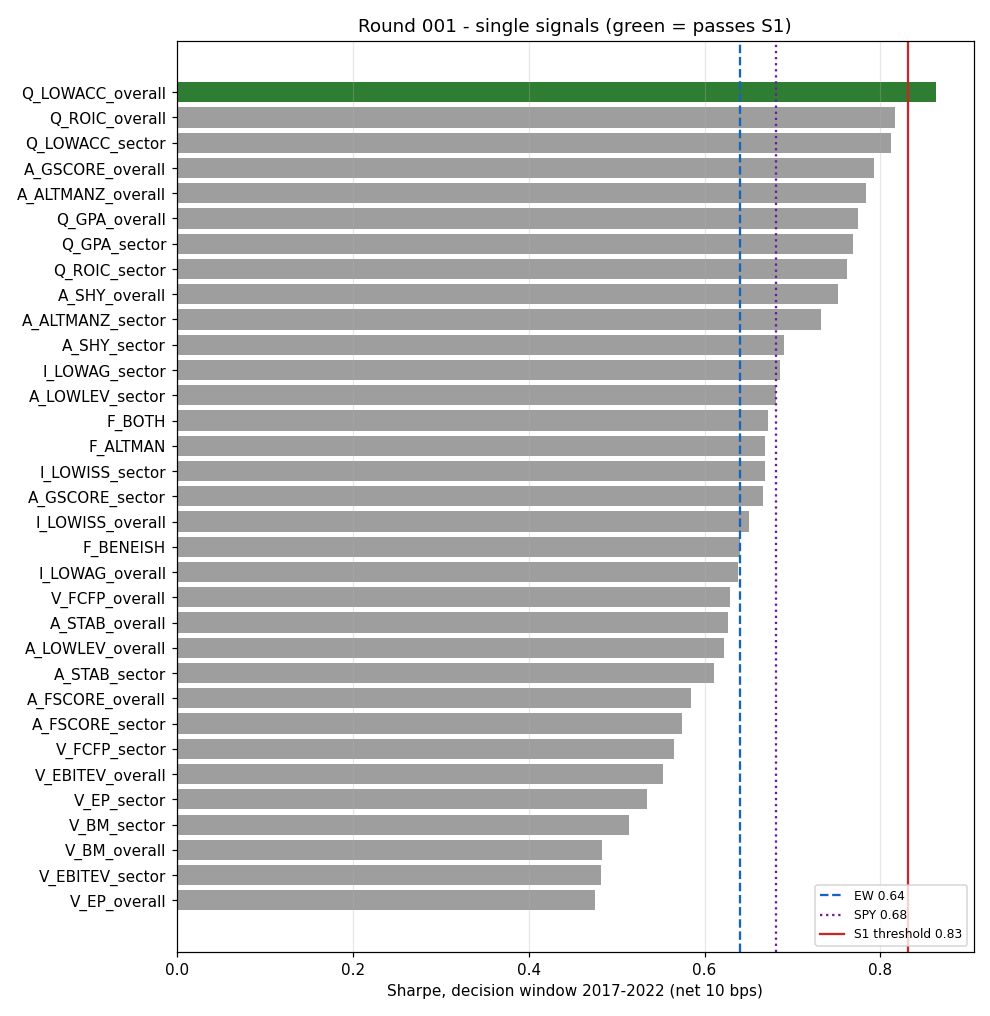

In [2]:
for f in sorted(pathlib.Path("../figures").glob("round_001_*.png")): display(Image(filename=str(f)))

In [3]:
display(Markdown(pathlib.Path("../rounds/round_001/RESULTS.md").read_text()))

# Round 001 — ผล (ตระกูล A: สัญญาณเดี่ยว) — **ไม่มีผู้เข้ารอบ**

- trial ในรอบนี้ 33 → สะสม **45** (`trials.csv`); ตารางเต็ม: `results.csv`; กราฟ: `figures/round_001_sharpe.png`, `figures/round_001_nav.png`
- benchmark ช่วงตัดสิน (2017–2022, net 10 bps): EW(U) Sharpe 0.640 · SPY 0.681 → เกณฑ์ S1 ต้องได้ Sharpe ≥ 0.831

| ผลสำคัญ | ตัวเลข |
|---|---|
| ผ่าน S1 (ทั้ง 10 และ 25 bps) | 1 ตัว: `Q_LOWACC_overall` (Sharpe 0.863, CAGR 18.6% vs EW 12.5%, MDD −36.2% vs −37.6%) |
| ตัวเดียวกันที่ S2 / S6 | ผ่าน (100% ของหน้าต่าง 36 เดือน; ถือเฉลี่ย 63 ต่ำสุด 51) |
| **ตัวเดียวกันที่ S3** | **ตก: DSR = 0.860 < 0.95** (N = 45 trial) |
| ตัวเดียวกันช่วงประกอบ 2011–2016 | Sharpe 0.787 **แพ้** EW 1.137 |
| value ทุกตัว (BM, E/P, EBIT/EV, FCF/P) | แพ้ EW ใน Sharpe ช่วงตัดสิน (0.475–0.629) |
| quality (GP/A, ROIC, G-score, Altman Z) | ชนะ EW แต่ไม่ถึงเกณฑ์ S1 (0.762–0.817) |
| ตัวกรอง Altman/Beneish | ใกล้ EW (0.640–0.673) — ตัดหุ้นออกน้อย (Beneish คำนวณได้แค่ ~20–26% ของ universe) |
| A_STAB | ตก S6 (รอบ 2011 มีหุ้นที่คำนวณได้แค่ 5 ตัว เพราะต้องมีประวัติ ≥ 3 ปี) |
| walk-forward | corr(Sharpe ส่วนเกินช่วงประกอบ, ช่วงตัดสิน) = **−0.247**; ตัวที่ดีที่สุดในช่วงประกอบ (`A_STAB_sector` +0.285) แพ้ EW ในช่วงตัดสิน (−0.030) |

## การตีความ
- สัญญาณ "คุณภาพ" (กำไรจริงเป็นเงินสด, ผลตอบแทนต่อเงินทุน) ทำได้ดีกว่า "ความถูก" ในช่วง 2017–2022 — สอดคล้องกับ v1
- แต่ความได้เปรียบ **ไม่เสถียรข้ามช่วงเวลา** (ช่วงประกอบกลับด้าน, walk-forward ติดลบ) และตัวที่ดีที่สุดยังตก S3
  หลังปรับการลองหลายครั้ง → เป็นไปได้สูงว่าเป็นผลของช่วงเวลา/โชค ไม่ใช่ความได้เปรียบทนทาน
- ไม่มีการลดเกณฑ์ — ไปต่อที่ตระกูล B (คะแนนรวม) ตามแผน
